## 04 - Tree Model (XGBoost & LightGBM)

Train XGBoost and LightGBM on the label-encoded tree dataset and compares both against the logistic regression (PR-AUC: 0.7064).

Tree models capture non-linear feature interactions and handle raw numeric features (e.g. `amount`, `velocity_1h`) without scaling. Imbalance is handled via `scale_pos_weight` (XGBoost) and `is_unbalance = True` (LightGBM). Primary metric: **PR-AUC**.

### Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    classification_report, precision_recall_curve,
    PrecisionRecallDisplay, RocCurveDisplay
)

### Load Data

In [15]:
data_dir = Path("../Data/Processed")
train = pd.read_csv(data_dir / "train_tree.csv")
test = pd.read_csv(data_dir / "test_tree.csv")

### Prepare Features & Target

In [16]:
FEATURE_COLS = [c for c in train.columns if c != "is_fraud"]
TARGET = "is_fraud"

x_train = train[FEATURE_COLS].fillna(0)
y_train = train[TARGET]
x_test = test[FEATURE_COLS].fillna(0)
y_test = test[TARGET]

In [17]:
print(f"Train: {len(train):,} rows | fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test: {len(test):,} rows | fraud rate: {y_test.mean()*100:.2f}%")

Train: 666,085 rows | fraud rate: 1.71%
Test: 333,915 rows | fraud rate: 1.71%


### Train XGBoost

`scale_pos_weight` upweights the minority fraud class by the ratio of negatives to positives (~57x), equivalent to `class_weight = "balanced"` in sklearn.

In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

xgb_model = XGBClassifier(
    objective               = "binary:logistic",
    eval_metric             = "aucpr",
    scale_pos_weight        = scale_pos_weight,
    max_depth               = 6,
    learning_rate           = 0.05,
    n_estimators            = 500,
    subsample               = 0.8,
    colsample_bytree        = 0.8,
    random_state            = 42,
    early_stopping_rounds   = 50
)
xgb_model.fit(x_train, y_train, eval_set = [(x_test, y_test)], verbose = 100)
print(f"\nBest iteration: {xgb_model.best_iteration}")

scale_pos_weight: 57.3
[0]	validation_0-aucpr:0.51921
[100]	validation_0-aucpr:0.80560
[200]	validation_0-aucpr:0.82362
[300]	validation_0-aucpr:0.82548
[344]	validation_0-aucpr:0.82434

Best iteration: 294


### Train LightGBM

`is_unbalance = True` automatically adjusts class weight. Early stopping monitors PR-AUC on the test set.

In [19]:
lgb_model = LGBMClassifier(
    objective          = "binary",
    metric             = "average_precision",
    is_unbalance       = True,
    max_depth          = 6,
    learning_rate      = 0.05,
    n_estimators       = 500,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    random_state       = 42,
    verbose            = -1
)

lgb_model.fit(
    x_train, y_train,
    eval_set = [(x_test, y_test)],
    callbacks = [lgb.early_stopping(50), lgb.log_evaluation(100)]
)
print(f"\nBest iteration: {lgb_model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's average_precision: 0.803165
[200]	valid_0's average_precision: 0.822497
[300]	valid_0's average_precision: 0.826193
[400]	valid_0's average_precision: 0.82712
Early stopping, best iteration is:
[403]	valid_0's average_precision: 0.82736

Best iteration: 403


### Evaluate Models

In [20]:
LR_PR_AUC = 0.7064
LR_ROC_AUC = 0.9741

xgb_proba = xgb_model.predict_proba(x_test)[:, 1]
lgb_proba = lgb_model.predict_proba(x_test)[:, 1]

xgb_pr_auc = average_precision_score(y_test, xgb_proba)
xgb_roc_auc = roc_auc_score(y_test, xgb_proba)

lgb_pr_auc = average_precision_score(y_test, lgb_proba)
lgb_roc_auc = roc_auc_score(y_test, lgb_proba)

print(f"{'Model':<22} {'PR-AUC':>10} {'vs LR':>10} {'ROC-AUC':>10}")
print("-" * 54)
print(f"{'Logistic Regression':<22} {LR_PR_AUC:10.4f} {'-':>10} {LR_ROC_AUC:>10.4f}")
print(f"{'XGBoost':<22} {xgb_pr_auc:>10.4f} {xgb_pr_auc - LR_PR_AUC:>+10.4f} {xgb_roc_auc:>10.4f}")
print(f"{'LightGBM':<22} {lgb_pr_auc:>10.4f} {lgb_pr_auc - LR_PR_AUC:>+10.4f} {lgb_roc_auc:>10.4f}")

Model                      PR-AUC      vs LR    ROC-AUC
------------------------------------------------------
Logistic Regression        0.7064          -     0.9741
XGBoost                    0.8257    +0.1193     0.9897
LightGBM                   0.8274    +0.1210     0.9895


In [21]:
xgb_pred = (xgb_proba >= 0.5).astype(int)
lgb_pred = (lgb_proba >= 0.5).astype(int)

print("XGBoost (threshold = 0.5):")
print(classification_report(y_test, xgb_pred, target_names = ["Legit", "Fraud"]))

print("LightGBM (threshold = 0.5):")
print(classification_report(y_test, lgb_pred, target_names = ["Legit", "Fraud"]))

XGBoost (threshold = 0.5):
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98    328190
       Fraud       0.30      0.93      0.45      5725

    accuracy                           0.96    333915
   macro avg       0.65      0.94      0.72    333915
weighted avg       0.99      0.96      0.97    333915

LightGBM (threshold = 0.5):
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98    328190
       Fraud       0.29      0.93      0.44      5725

    accuracy                           0.96    333915
   macro avg       0.64      0.94      0.71    333915
weighted avg       0.99      0.96      0.97    333915



### Threshold Tuning

In [22]:
def optimal_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
    best_idx = f1_scores.argmax()
    return thresholds[best_idx], f1_scores[best_idx]

xgb_thresh, xgb_f1 = optimal_threshold(y_test, xgb_proba)
lgb_thresh, lgb_f1 = optimal_threshold(y_test, lgb_proba)

print(f"XGBoost - optimal threshold: {xgb_thresh:.3f} | F1: {xgb_f1:.4f}")
print(f"LightGBM - optimal threshold: {lgb_thresh:.3f} | F1: {lgb_f1:.4f}")

XGBoost - optimal threshold: 0.948 | F1: 0.7521
LightGBM - optimal threshold: 0.962 | F1: 0.7566


In [23]:
xgb_pred_opt = (xgb_proba >= xgb_thresh).astype(int)
lgb_pred_opt = (lgb_proba >= lgb_thresh).astype(int)

print(f"XGBoost at optimal threshold ({xgb_thresh:.3f}):")
print(classification_report(y_test, xgb_pred_opt, target_names = ["Legit", "Fraud"]))

print(f"LightGBM at optimal threshold ({lgb_thresh:.3f}):")
print(classification_report(y_test, lgb_pred_opt, target_names = ["Legit", "Fraud"]))

XGBoost at optimal threshold (0.948):
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    328190
       Fraud       0.78      0.73      0.75      5725

    accuracy                           0.99    333915
   macro avg       0.89      0.86      0.87    333915
weighted avg       0.99      0.99      0.99    333915

LightGBM at optimal threshold (0.962):
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00    328190
       Fraud       0.83      0.70      0.76      5725

    accuracy                           0.99    333915
   macro avg       0.91      0.85      0.88    333915
weighted avg       0.99      0.99      0.99    333915



### Precision-Recall & ROC Curves

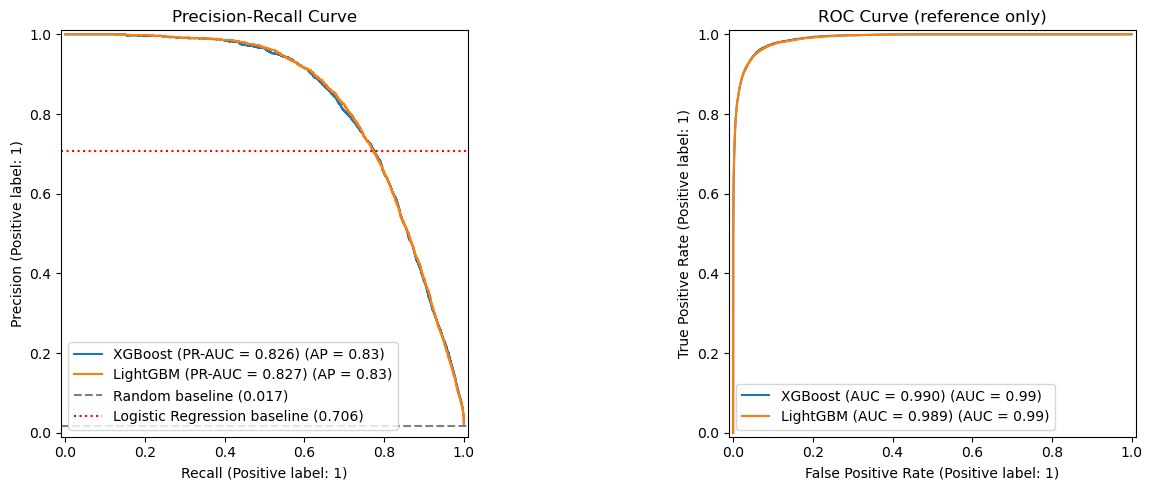

In [24]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

PrecisionRecallDisplay.from_predictions(
    y_test, xgb_proba, ax = axes[0], name = f"XGBoost (PR-AUC = {xgb_pr_auc:.3f})")
PrecisionRecallDisplay.from_predictions(
    y_test, lgb_proba, ax =axes[0], name = f"LightGBM (PR-AUC = {lgb_pr_auc:.3f})")
axes[0].axhline(y_test.mean(), color = "gray", linestyle = "--",
                label = f"Random baseline ({y_test.mean():.3f})")
axes[0].axhline(LR_PR_AUC, color = "red", linestyle = ":", 
                label = f"Logistic Regression baseline ({LR_PR_AUC:.3f})")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()

RocCurveDisplay.from_predictions(
    y_test, xgb_proba, ax = axes[1], name = f"XGBoost (AUC = {xgb_roc_auc:.3f})")
RocCurveDisplay.from_predictions(
    y_test, lgb_proba, ax = axes[1], name = f"LightGBM (AUC = {lgb_roc_auc:.3f})")
axes[1].set_title("ROC Curve (reference only)")
axes[1].legend()

plt.tight_layout()

### Feature Importance

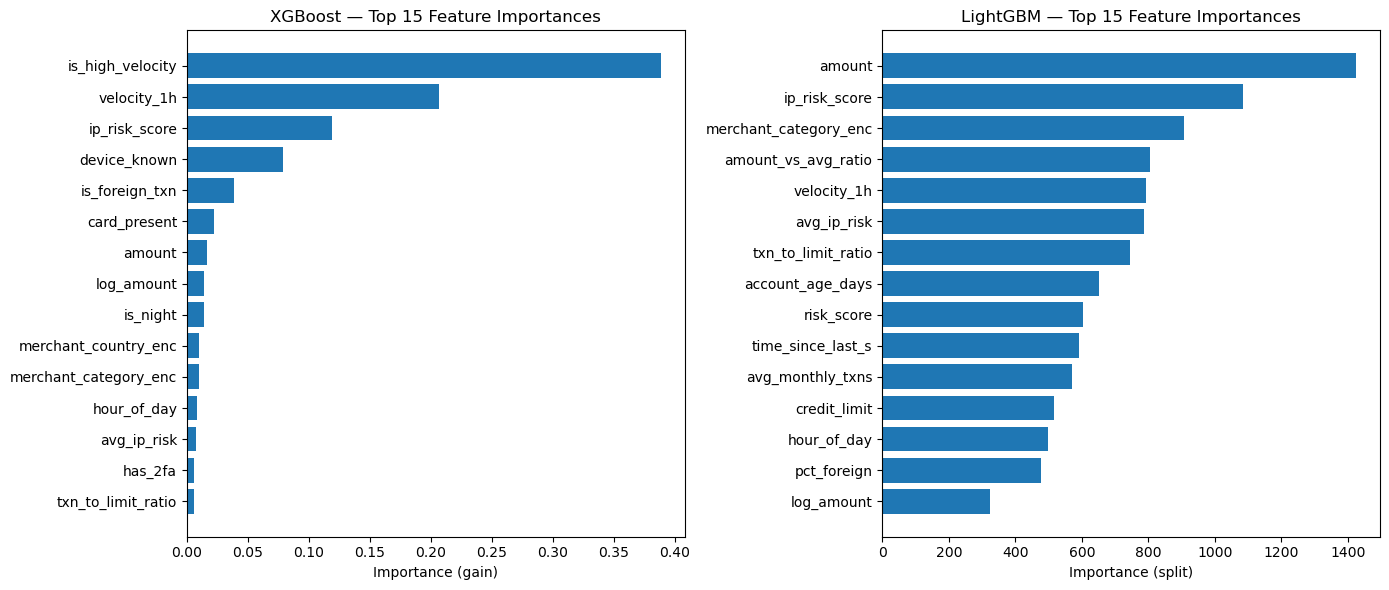

In [25]:
top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).nlargest(top_n)
axes[0].barh(xgb_imp.index[::-1], xgb_imp.values[::-1])
axes[0].set_title(f"XGBoost — Top {top_n} Feature Importances")
axes[0].set_xlabel("Importance (gain)")

lgb_imp = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS).nlargest(top_n)
axes[1].barh(lgb_imp.index[::-1], lgb_imp.values[::-1])
axes[1].set_title(f"LightGBM — Top {top_n} Feature Importances")
axes[1].set_xlabel("Importance (split)")

plt.tight_layout()


### Summary

In [26]:
print(f"{'Model':<22} {'PR-AUC':>10} {'vs LR':>10} {'ROC-AUC':>10}")
print("-" * 54)
print(f"{'Logistic Regression':<22} {LR_PR_AUC:>10.4f} {'—':>10} {LR_ROC_AUC:>10.4f}")
print(f"{'XGBoost':<22} {xgb_pr_auc:>10.4f} {xgb_pr_auc - LR_PR_AUC:>+10.4f} {xgb_roc_auc:>10.4f}")
print(f"{'LightGBM':<22} {lgb_pr_auc:>10.4f} {lgb_pr_auc - LR_PR_AUC:>+10.4f} {lgb_roc_auc:>10.4f}")

Model                      PR-AUC      vs LR    ROC-AUC
------------------------------------------------------
Logistic Regression        0.7064          —     0.9741
XGBoost                    0.8257    +0.1193     0.9897
LightGBM                   0.8274    +0.1210     0.9895


### Save Predictions


In [ ]:
pd.DataFrame({
    "y_test":    y_test.values,
    "xgb_proba": xgb_proba,
    "lgb_proba": lgb_proba
}).to_csv(data_dir / "predictions_tree.csv", index=False)

print("Saved predictions_tree.csv")

Saved predictions_tree.csv
